<a href="https://colab.research.google.com/github/MichalSlowakiewicz/DNN-Homeworks/blob/master/LAB_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ViT – Intro
In this lab scenario you are going to finish the implementation of [Vision Transformer](https://arxiv.org/abs/2010.11929) and train it on [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html).

Briefly, ViT can be summarized as follows:
* Take the input image and divide it into patches of predefined size.
* Project the patches to vectors and add learned positional encodings.
* Add a learned classification token.
* Process tokens with the transformer.
* Use the output at the classification token for classification.

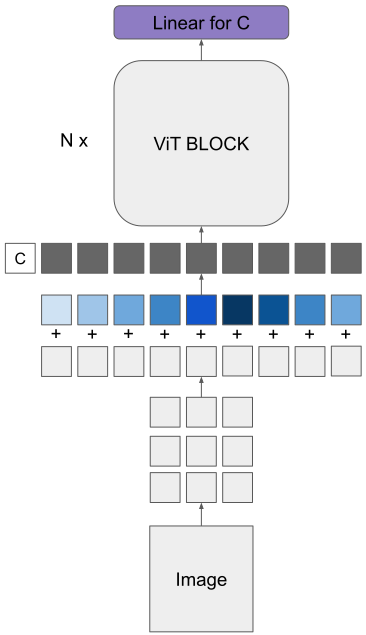

## Imports

In [1]:
!pip install lightning --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 8.8 MB/s eta 0:00:00


In [2]:
from pathlib import Path

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
from lightning.pytorch.callbacks import RichModelSummary
from lightning.pytorch.loggers import TensorBoardLogger
from torch import Tensor
from torchvision.transforms import v2

## Dataset

In [3]:
BATCH_SIZE = 32
IMAGE_SHAPE = 3, 72, 72  # C, H, W
mean, std = (0.5, 0.5, 0.5), (0.25, 0.25, 0.25)

image_transform = v2.Compose(
    [
        v2.Resize(IMAGE_SHAPE[1:], interpolation=v2.InterpolationMode.BILINEAR),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean, std),
    ]
)

train_transform = v2.Compose(
    [
        # v2.AutoAugment(v2.AutoAugmentPolicy.CIFAR10),
        image_transform,
    ]
)

to_pil_image = v2.Compose(
    [
        v2.Normalize([-m / s for m, s in zip(mean, std)], [1 / s for s in std]),
        v2.ToPILImage(),
        v2.Resize(128, interpolation=v2.InterpolationMode.NEAREST),
    ]
)

dataset_path = Path("./data/CIFAR10/")
dataset_path.mkdir(parents=True, exist_ok=True)
train_dataset = torchvision.datasets.CIFAR10(
    dataset_path, train=True, download=True, transform=train_transform
)
val_dataset = torchvision.datasets.CIFAR10(
    dataset_path, train=False, download=True, transform=image_transform
)
classes = train_dataset.classes
NUM_CLASSES = len(classes)
print("Classes:", classes)

loader_kwargs = {"batch_size": BATCH_SIZE, "num_workers": 2, "pin_memory": False}
train_loader = torch.utils.data.DataLoader(train_dataset, **loader_kwargs, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, **loader_kwargs, shuffle=False)

100%|██████████| 170M/170M [00:04<00:00, 41.4MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


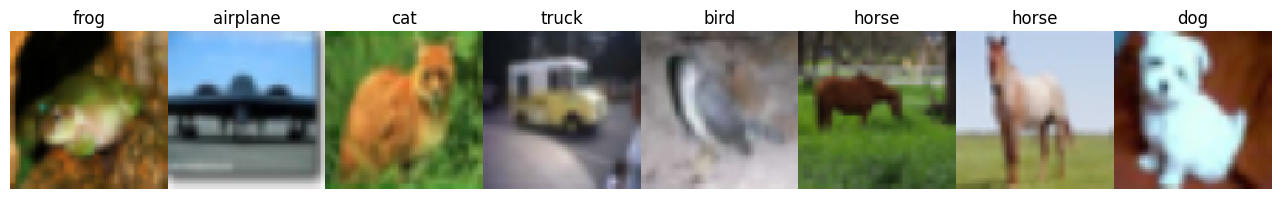

In [4]:
def show_images(
    images: torch.Tensor, labels: list[int], n_rows: int = 1, n_cols: int = 8
) -> None:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 2 * n_rows))
    fig.set_layout_engine("compressed", h_pad=0.1, w_pad=0, hspace=0, wspace=0)
    if n_rows == 1 == n_cols:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[None, :]
    elif n_cols == 1:
        axes = axes[:, None]
    for i, img in enumerate(images[: n_rows * n_cols]):
        r, c = divmod(i, n_cols)
        axes[r, c].imshow(to_pil_image(img))
        axes[r, c].axis("off")
        axes[r, c].set_title(classes[labels[i]])


image_batch, label_batch = next(iter(train_loader))
show_images(image_batch, label_batch)

## Patch embedder
Implement the patch embedder (which turns images into a sequence of tokens), as specified in docstrings.

Use a standard deviation of 0.02 when initializing the learned positional encoder parameters.

In [5]:
class ViTPatchEmbedder(nn.Module):
    """
    Turns images into a sequence of tokens with learned positional encoding.

    Args:
        input_shape: (C, H, W) shape of input images.
        patch_size: size of each patch (patches are square).
        d_model: dimension of output tokens.
    """

    def __init__(
        self, input_shape: tuple[int, int, int], patch_size: int, d_model: int
    ) -> None:
        super().__init__()
        assert len(input_shape) == 3
        assert input_shape[1] % patch_size == 0 == input_shape[2] % patch_size
        self.input_shape = input_shape
        self.patch_size = patch_size
        self.d_model = d_model
        self.num_patches = (input_shape[1] // patch_size) * (
            input_shape[2] // patch_size
        )

        # TODO { # projection layer and learned positional encoding
        if False:
          self.projection_layer = nn.Linear(input_shape[0] * patch_size**2, d_model)
        # alternatively
        self.conv = nn.Conv2d(3, d_model, kernel_size=patch_size, stride=patch_size)
        self.positional_encoding = nn.Parameter(torch.randn(1, self.num_patches, self.d_model)*0.02)
        # }

    def _patch_embed(self, x: Tensor) -> Tensor:
        """
        Input: shape (B, C, H, W) normalized image.
        Output: shape (B, num_patches, d_model) projected patches.
        """
        B, C, H, W = x.shape
        assert (C, H, W) == self.input_shape
        # TODO {
        P = self.patch_size

        if False:
          n_H = H // self.patch_size
          n_W = W // self.patch_size

          x = x.view(B, C, n_H, self.patch_size, n_W, self.patch_size)

          # number of patches n_H * n_W
          num_patches = n_H * n_W
          x = torch.permute(x, (0, 2, 4, 1, 3, 5)) # (B, n_H, n_W, C, P, P)
          x = x.view(B, num_patches, C*self.patch_size*self.patch_size) # (B, P*P*C, self.num_patches)
          x = self.projection_layer(x)
        # }
        else:
          x = self.conv(x)
          n_H = H // self.patch_size
          n_W = W // self.patch_size
          num_patches = n_H * n_W
          x = x.view(B, self.d_model, num_patches)
          x = x.permute(0,2,1)
        assert x.shape == (B, self.num_patches, self.d_model)
        return x

    def _apply_positional_encoding(self, x: Tensor) -> Tensor:
        """
        Input: shape (B, num_patches, d_model) projected patches.
        Output: shape (B, num_patches, d_model) projected patches with positional encoding.
        """
        B = x.shape[0]
        assert x.shape == (B, self.num_patches, self.d_model)
        # TODO {
        x = x + self.positional_encoding
        # }
        assert x.shape == (B, self.num_patches, self.d_model)
        return x

    def forward(self, x: Tensor) -> Tensor:
        """
        Input: shape (B, C, H, W) normalized image.
        Output: shape (B, num_patches, d_model) projected patches with positional encoding.
        """
        x = self._patch_embed(x)  # shape (B, num_patches, d_model)
        x = self._apply_positional_encoding(x)
        return x


PATCH_SIZE = 4  # we will divide image into squares of size 4x4
D_MODEL = 32  # we will project each patch into a vector of length 32
ViTPatchEmbedder(IMAGE_SHAPE, patch_size=PATCH_SIZE, d_model=D_MODEL)(image_batch).shape

torch.Size([32, 324, 32])

## ViT Layer

Finish the implementation of transformer MLP layer according to docstrings.

In [7]:
class VitMLP(nn.Module):
    """
    MLP used in ViT layers.

    d_model → d_hidden → d_model, GELU activation between dense layers, dropout after every dense layer.
    """

    def __init__(self, d_model: int, d_hidden: int, dropout: float = 0.1) -> None:
        super().__init__()
        self.d_model = d_model
        self.d_hidden = d_hidden
        # TODO {
        self.layers = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(d_hidden, d_model),
            nn.Dropout(p=dropout),

        )
        # }

    def forward(self, x: Tensor) -> Tensor:
        assert x.shape[-1] == self.d_model
        # TODO {
        x = self.layers(x)
        # }
        assert x.shape[-1] == self.d_model
        return x

Afterwards, finish the implementation of `ViTBlock` according to docstrings and the following image.
**FF is the MLP, MHA here is self-attention.**

Use [nn.MultiheadAttention](https://docs.pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html) and check its documentation.
Pay attention to the `batch_first` argument of `__init__`, the first three arguments of `forward()`, and its return type.

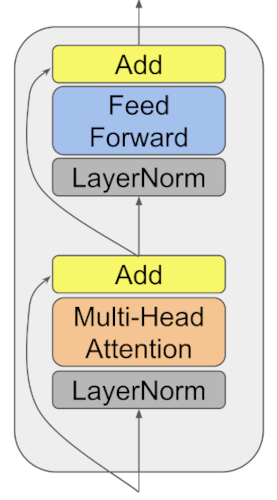

In [10]:
class ViTBlock(nn.Module):
    """A ViT layer."""

    def __init__(
        self, d_model: int, d_hidden: int, num_heads: int, dropout: float = 0.1
    ) -> None:
        super().__init__()


        self.d_model = d_model
        self.d_hidden = d_hidden
        self.num_heads = num_heads

        # TODO {
        self.mlp = VitMLP(d_model, d_hidden,dropout=dropout)
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.mha = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)

        # }

    def forward(self, x: Tensor) -> Tensor:
        """
        Input and output: shape (B, S, d_model) sequence of tokens.
        """
        assert len(x.shape) == 3
        assert x.shape[-1] == self.d_model

        # TODO {
        x_norm = self.layernorm1(x)
        attn, _ = self.mha(x_norm, x_norm, x_norm)
        x = x + attn


        x_norm = self.layernorm2(x)
        x = self.mlp(x_norm) + x

        # }

        assert len(x.shape) == 3
        assert x.shape[-1] == self.d_model
        return x

Finish the implementation of ViT according to docstrings.

In [ ]:
class ViT(nn.Module):
    """
    * Embeds images (B, C, H, W) with ViTPatchEmbedder (where (C, H, W)=input_shape).
    * Appends a learned token to the sequence, resulting in shape (B, num_patches + 1, d_model).
    * Processes the sequence with `num_layers` ViTBlocks.
    * Computes classification logits (pre-softmax) from the class. token with a linear layer.
    """

    def __init__(
        self,
        input_shape: tuple[int, int, int],
        patch_size: int,
        d_model: int,
        d_hidden: int,
        num_heads: int,
        num_layers: int,
        num_classes: int,
    ):
        super().__init__()
        self.input_shape = input_shape
        self.num_classes = num_classes
        # TODO {
        self.vit_patch_emb = ViTPatchEmbedder(input_shape=input_shape, patch_size=patch_size, d_model=d_model)

        # }

    def forward(self, x):
        B, C, H, W = x.shape
        assert (C, H, W) == self.input_shape
        # TODO {
        embed = self.vit_patch_emb(x)

        # }
        assert x.shape == (B, self.num_classes)
        return x

## Training
Now let's train the model. You can experiment with the parameters here. However, do not expect very good results on such a small dataset. ViT shines when pre-trained on large image datasets.  
You should be able to get accuracy > 0.6 on the test set.

In [ ]:
vit = ViT(
    input_shape=IMAGE_SHAPE,
    patch_size=PATCH_SIZE,
    d_model=32,
    d_hidden=16,
    num_heads=4,
    num_layers=3,
    num_classes=NUM_CLASSES,
)

assert vit(image_batch).shape == (BATCH_SIZE, NUM_CLASSES)

In [ ]:
class ViTLightningModule(L.LightningModule):
    def __init__(self, model: nn.Module) -> None:
        super().__init__()

        self.model = model

    def train_dataloader(self) -> torch.utils.data.DataLoader:
        return train_loader

    def val_dataloader(self) -> torch.utils.data.DataLoader:
        return val_loader

    def training_step(self, batch: tuple[Tensor, Tensor], batch_idx: int) -> Tensor:
        x, gt_label = batch
        logits = self.model(x)
        loss = torch.nn.functional.cross_entropy(logits, gt_label)

        with torch.no_grad():
            pred = torch.argmax(logits, dim=-1)
            accuracy = (pred == gt_label).type(torch.float32).mean()

        self.log("train/loss", loss.detach())
        self.log("train/acc", accuracy.detach(), prog_bar=True)

        return loss

    def validation_step(self, batch: tuple[Tensor, Tensor], batch_idx: int) -> None:
        x, gt_label = batch
        logits = self.model(x)
        pred = torch.argmax(logits, dim=-1)
        accuracy = (pred == gt_label).type(torch.float32).mean()

        self.log("test/acc", accuracy.detach(), on_epoch=True, prog_bar=True)

    def configure_optimizers(self) -> torch.optim.Optimizer:
        return torch.optim.Adam(self.model.parameters())

In [ ]:
%load_ext tensorboard
# !rm -rf runs/
!mkdir -p runs
%tensorboard --logdir runs

In [ ]:
trainer = L.Trainer(
    logger=TensorBoardLogger("runs", name="vit"),
    max_epochs=10,
    check_val_every_n_epoch=1,
    enable_model_summary=False,
    callbacks=[RichModelSummary(max_depth=2)]
)

trainer.fit(ViTLightningModule(vit))